In [1]:
import sys
import os
import matplotlib.pyplot as plt

# Add the project root to the Python path to allow importing from 'src'
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.quantum_validator import QuantumValidator
from src.blockchain import Block
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [2]:
# These parameters define the rules of our quantum validation
NUM_QUBITS = 4
# For a block to be valid, its quantum circuit must produce this state most often
TARGET_STATE = '1' * NUM_QUBITS 

print(f"Validation requires the quantum circuit to measure '{TARGET_STATE}'")

Validation requires the quantum circuit to measure '1111'


Data: 'Hello, Quantum Blockchain!'
Hash: baae5802b732e643dc287704f1094ecc0540bb057c74a2e6796e7876b4354ba8

This hash generates the following unique quantum circuit (the 'fingerprint'):


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:269: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\qiskit\visualization\circuit\styles\iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(self._style)


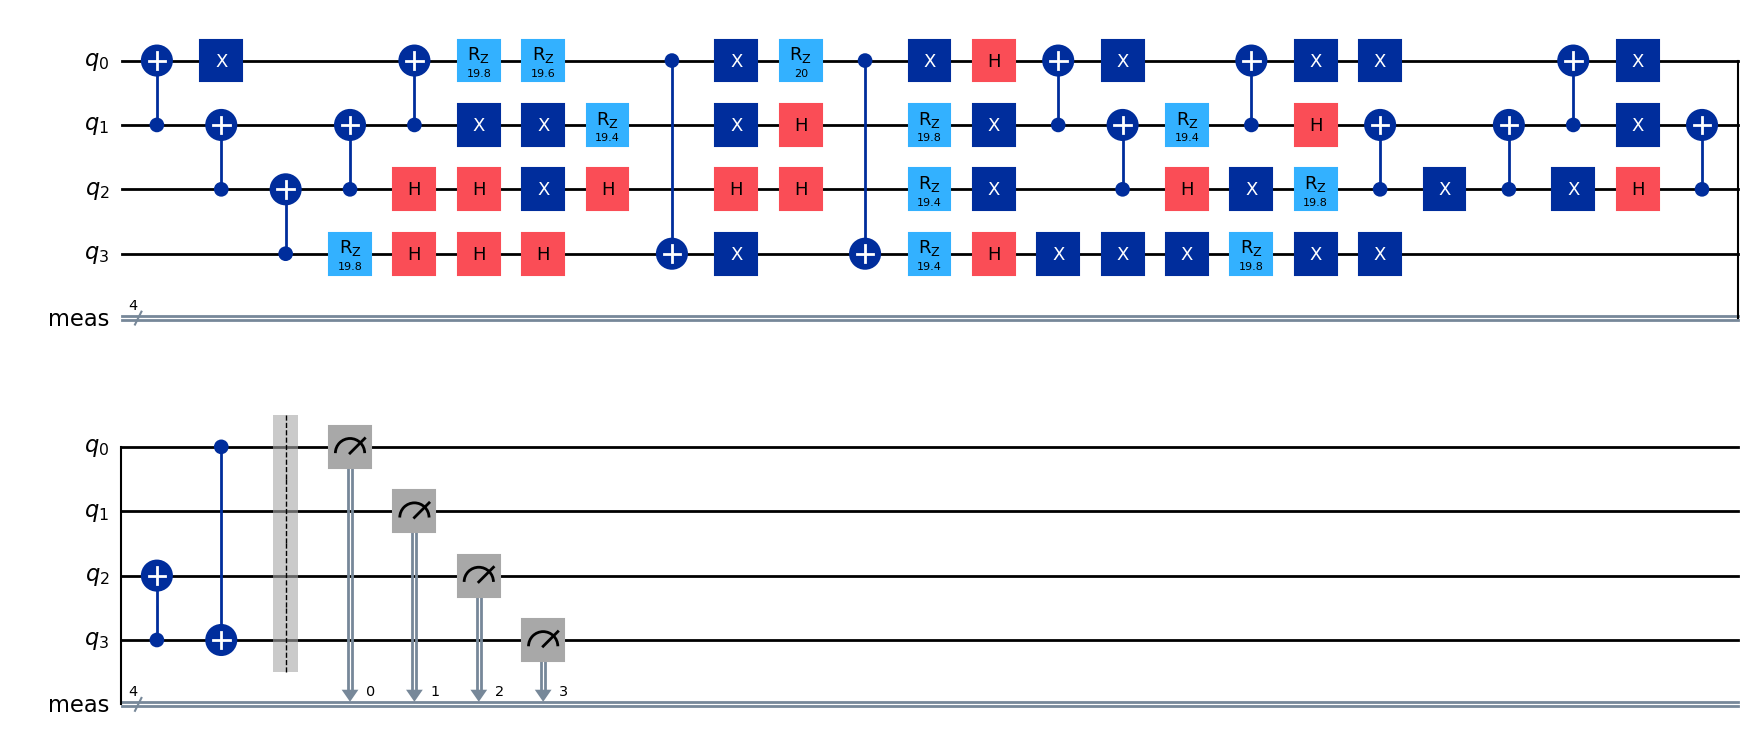

In [3]:
# Let's see how a block's data is converted into a unique quantum circuit.

# 1. Create a sample block
sample_block = Block(index=1, data="Hello, Quantum Blockchain!", previous_hash="0"*64)
block_hash = sample_block.calculate_hash()

print(f"Data: '{sample_block.data}'")
print(f"Hash: {block_hash}")

# 2. Generate the quantum circuit from this hash
validator = QuantumValidator(num_qubits=NUM_QUBITS, target_state=TARGET_STATE)
validation_circuit = validator._generate_circuit_from_hash(block_hash)

print("\nThis hash generates the following unique quantum circuit (the 'fingerprint'):")
display(validation_circuit.draw('mpl', style='iqx'))

The most frequent measurement outcome was: '1000'
The required target state is:             '1111'

Is the block valid? -> False


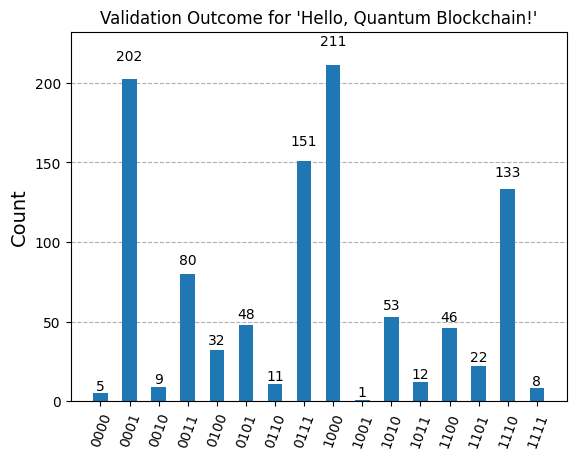

In [4]:
# Now, let's run the circuit and see if the block is valid.

# 1. Simulate the circuit
backend = AerSimulator()
result = backend.run(validation_circuit, shots=1024).result()
counts = result.get_counts()

# 2. Find the most frequent outcome
most_frequent_outcome = max(counts, key=counts.get)

# 3. Check against the target state
is_valid = (most_frequent_outcome == TARGET_STATE)

print(f"The most frequent measurement outcome was: '{most_frequent_outcome}'")
print(f"The required target state is:             '{TARGET_STATE}'")
print(f"\nIs the block valid? -> {is_valid}")

# 4. Visualize the results
plot_histogram(counts, title=f"Validation Outcome for '{sample_block.data}'")

Original Hash: baae5802b732e643dc287704f1094ecc0540bb057c74a2e6796e7876b4354ba8
Tampered Hash: 9c917c3bd525d5ed8bbe6bcf04d690289133cb42cdd5cd4962cb9cd6fa75b530

Notice the hash is completely different!

The tampered hash generates a completely different quantum circuit:


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:269: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\qiskit\visualization\circuit\styles\iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(self._style)


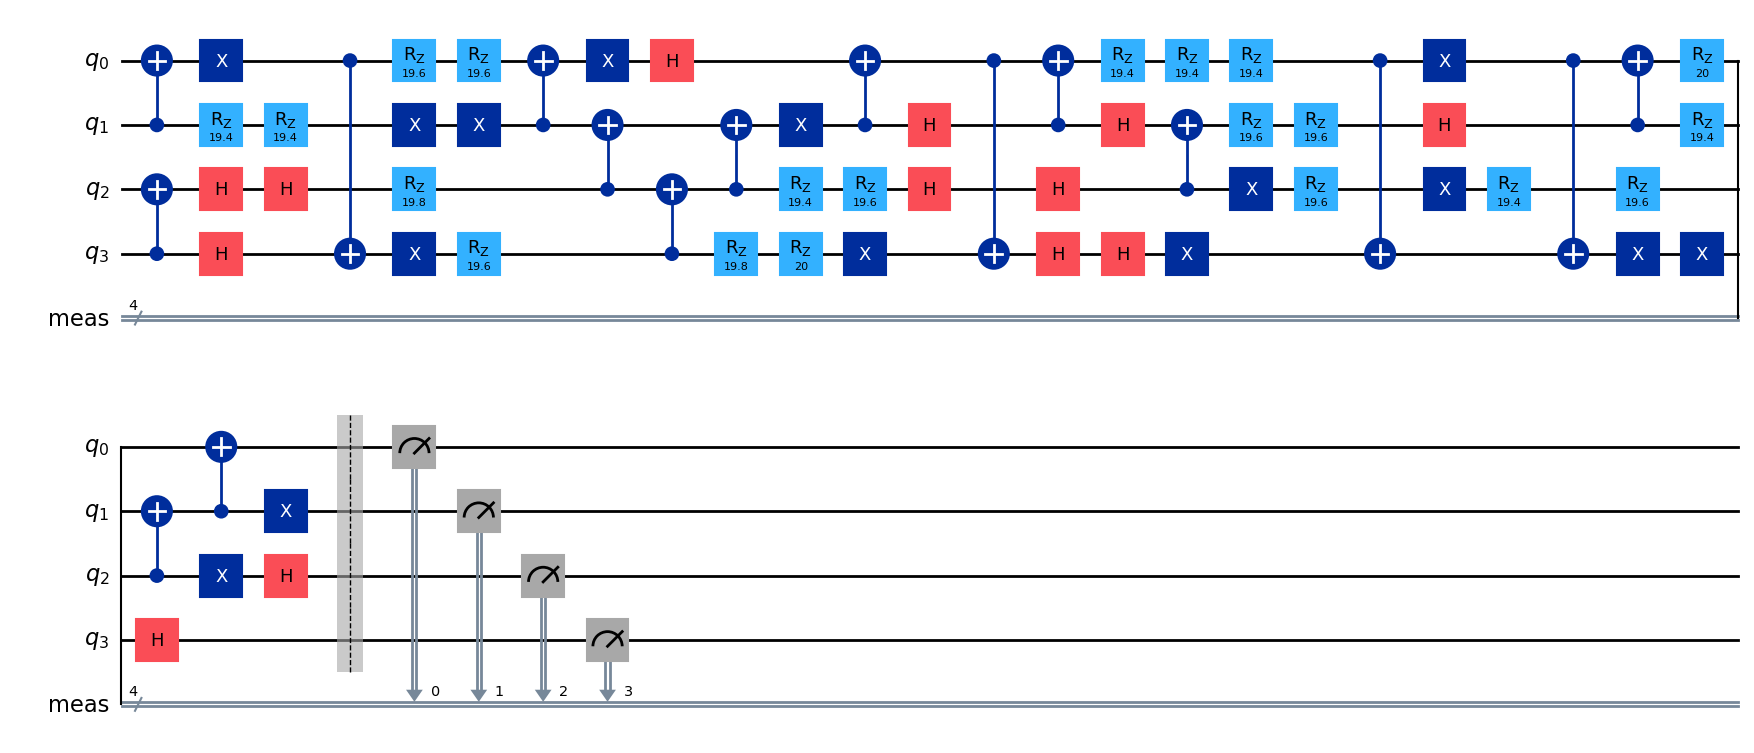

In [5]:
# Let's tamper with the block's data and see what happens.

# 1. Create a tampered version of the block
tampered_block = Block(index=1, data="Evil Tampered Data!", previous_hash="0"*64)
tampered_hash = tampered_block.calculate_hash()

print(f"Original Hash: {block_hash}")
print(f"Tampered Hash: {tampered_hash}")
print("\nNotice the hash is completely different!")

# 2. Generate the new quantum circuit from the tampered hash
tampered_circuit = validator._generate_circuit_from_hash(tampered_hash)

print("\nThe tampered hash generates a completely different quantum circuit:")
display(tampered_circuit.draw('mpl', style='iqx'))

The most frequent outcome for the tampered block was: '0000'
The required target state is:                       '1111'

Is the tampered block valid? -> False


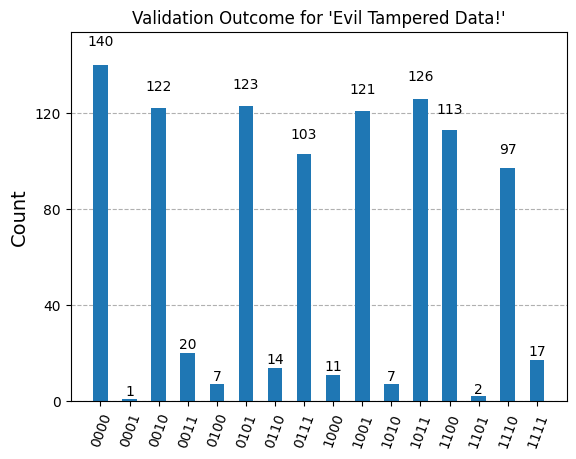

In [6]:
# Now, let's run the new circuit.

# 1. Simulate the tampered circuit
tampered_result = backend.run(tampered_circuit, shots=1024).result()
tampered_counts = tampered_result.get_counts()

# 2. Find the most frequent outcome
tampered_outcome = max(tampered_counts, key=tampered_counts.get)
is_tampered_valid = (tampered_outcome == TARGET_STATE)

print(f"The most frequent outcome for the tampered block was: '{tampered_outcome}'")
print(f"The required target state is:                       '{TARGET_STATE}'")
print(f"\nIs the tampered block valid? -> {is_tampered_valid}")

# 3. Visualize the new results
plot_histogram(tampered_counts, title=f"Validation Outcome for '{tampered_block.data}'")